# Advanced Financial Analytics

This notebook performs advanced financial analysis on mutual fund data by calculating risk and return metrics. The objective is to evaluate fund performance using industry-standard financial indicators and prepare the data for dashboard visualization.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

In [2]:
import os

os.listdir("../data/processed")

['alpha_beta.csv',
 'cagr_report.csv',
 'clean_investor_transactions.csv',
 'clean_nav_history.csv',
 'clean_scheme_performance.csv',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'returns_computed.csv',
 'sharpe_values.csv',
 'sortino_values.csv',
 'tracking_error.csv']

In [ ]:
## Load Processed Datasets
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

In [5]:
nav["date"] = pd.to_datetime(nav["date"], dayfirst=True)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [8]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [9]:
var_95 = (
    nav.groupby("amfi_code")["daily_return"]
       .quantile(0.05)
       .reset_index()
)

var_95.columns = ["amfi_code", "VaR_95"]

var_95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [ ]:
## Daily Return Calculation
def calculate_cvar(group):
    var = group["daily_return"].quantile(0.05)
    return group[group["daily_return"] <= var]["daily_return"].mean()

cvar_95 = (
    nav.groupby("amfi_code")
       .apply(calculate_cvar)
       .reset_index(name="CVaR_95")
)

cvar_95.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [11]:
var_cvar_report = var_95.merge(cvar_95, on="amfi_code")

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


In [13]:
rolling_stats = (
    nav.groupby("amfi_code")["daily_return"]
       .rolling(window=90)
       .agg(["mean", "std"])
       .reset_index()
)

rolling_stats.head()

,amfi_code,level_1,mean,std
0,100016,5750,NaN,NaN
1,100016,5751,NaN,NaN
2,100016,5752,NaN,NaN
3,100016,5753,NaN,NaN
4,100016,5754,NaN,NaN


In [14]:
rolling_stats["Rolling_Sharpe"] = (
    rolling_stats["mean"] / rolling_stats["std"]
) * np.sqrt(252)

rolling_stats.head()

,amfi_code,level_1,mean,std,Rolling_Sharpe
0,100016,5750,NaN,NaN,NaN
1,100016,5751,NaN,NaN,NaN
2,100016,5752,NaN,NaN,NaN
3,100016,5753,NaN,NaN,NaN
4,100016,5754,NaN,NaN,NaN


In [15]:
rolling_stats["date"] = nav["date"].values

In [16]:
rolling_stats.head()

,amfi_code,level_1,mean,std,Rolling_Sharpe,date
0,100016,5750,NaN,NaN,NaN,2022-01-03
1,100016,5751,NaN,NaN,NaN,2022-01-04
2,100016,5752,NaN,NaN,NaN,2022-01-05
3,100016,5753,NaN,NaN,NaN,2022-01-06
4,100016,5754,NaN,NaN,NaN,2022-01-07


In [17]:
rolling_stats.to_csv(
    "../reports/rolling_90day_sharpe.csv",
    index=False
)

print("Rolling Sharpe report saved successfully!")

Rolling Sharpe report saved successfully!


In [18]:
investor = pd.read_csv("../data/processed/clean_investor_transactions.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,01-01-2024,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,01-01-2024,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,01-01-2024,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,01-01-2024,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,01-01-2024,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [20]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"],
    dayfirst=True
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [21]:
investor["CohortMonth"] = (
    investor.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.to_period("M")
)

In [22]:
investor["TransactionMonth"] = (
    investor["transaction_date"]
    .dt.to_period("M")
)

In [23]:
investor["CohortIndex"] = (
    (investor["TransactionMonth"] - investor["CohortMonth"])
    .apply(lambda x: x.n)
)

In [24]:
cohort = investor.groupby(
    ["CohortMonth", "CohortIndex"]
)["investor_id"].nunique().reset_index()

In [25]:
cohort.head()

,CohortMonth,CohortIndex,investor_id
0,2024-01,0,1577
1,2024-01,1,540
2,2024-01,2,567
3,2024-01,3,541
4,2024-01,4,550


In [26]:
cohort_matrix = cohort.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="investor_id"
)

cohort_matrix.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
CohortMonth,,,,,,,,,,,,,,,,,
2024-01,1577.0,540.0,567.0,541.0,550.0,565.0,546.0,548.0,523.0,566.0,544.0,551.0,572.0,518.0,537.0,545.0,586.0
2024-02,990.0,356.0,367.0,352.0,352.0,350.0,375.0,342.0,315.0,348.0,348.0,354.0,316.0,347.0,319.0,324.0,NaN
2024-03,669.0,209.0,235.0,248.0,213.0,209.0,209.0,213.0,205.0,215.0,232.0,184.0,226.0,231.0,209.0,NaN,NaN
2024-04,441.0,120.0,137.0,139.0,128.0,139.0,150.0,128.0,132.0,140.0,129.0,137.0,135.0,140.0,NaN,NaN,NaN
2024-05,294.0,77.0,105.0,88.0,76.0,78.0,80.0,102.0,89.0,75.0,89.0,80.0,85.0,NaN,NaN,NaN,NaN


In [27]:
retention = cohort_matrix.divide(
    cohort_matrix[0],
    axis=0
) * 100

retention.round(2).head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
CohortMonth,,,,,,,,,,,,,,,,,
2024-01,100.0,34.24,35.95,34.31,34.88,35.83,34.62,34.75,33.16,35.89,34.50,34.94,36.27,32.85,34.05,34.56,37.16
2024-02,100.0,35.96,37.07,35.56,35.56,35.35,37.88,34.55,31.82,35.15,35.15,35.76,31.92,35.05,32.22,32.73,NaN
2024-03,100.0,31.24,35.13,37.07,31.84,31.24,31.24,31.84,30.64,32.14,34.68,27.50,33.78,34.53,31.24,NaN,NaN
2024-04,100.0,27.21,31.07,31.52,29.02,31.52,34.01,29.02,29.93,31.75,29.25,31.07,30.61,31.75,NaN,NaN,NaN
2024-05,100.0,26.19,35.71,29.93,25.85,26.53,27.21,34.69,30.27,25.51,30.27,27.21,28.91,NaN,NaN,NaN,NaN


In [28]:
retention.to_csv(
    "../reports/investor_cohort_analysis.csv"
)

print("Investor Cohort Analysis saved successfully!")

Investor Cohort Analysis saved successfully!


In [29]:
sip = investor.copy()

sip["Month"] = sip["transaction_date"].dt.to_period("M")

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,CohortMonth,TransactionMonth,CohortIndex,Month
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024-01,2024-01,0,2024-01
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024-01,2024-01,0,2024-01
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024-01,2024-01,0,2024-01
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024-01,2024-01,0,2024-01
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024-01,2024-01,0,2024-01


In [30]:
monthly_sip = (
    sip.groupby(["investor_id", "Month"])
       .size()
       .reset_index(name="Transactions")
)

monthly_sip.head()

,investor_id,Month,Transactions
0,INV000001,2024-11,1
1,INV000001,2025-01,2
2,INV000002,2024-03,1
3,INV000002,2024-07,1
4,INV000002,2024-09,1


In [31]:
sip_continuation = (
    monthly_sip.groupby("investor_id")["Month"]
               .count()
               .reset_index()
)

sip_continuation.columns = ["investor_id", "Active_Months"]

sip_continuation.head()

,investor_id,Active_Months
0,INV000001,2
1,INV000002,6
2,INV000003,2
3,INV000004,6
4,INV000005,6


In [32]:
sip_continuation["Continuation_Status"] = np.where(
    sip_continuation["Active_Months"] >= 6,
    "Consistent",
    "Dropped"
)

sip_continuation.head()

,investor_id,Active_Months,Continuation_Status
0,INV000001,2,Dropped
1,INV000002,6,Consistent
2,INV000003,2,Dropped
3,INV000004,6,Consistent
4,INV000005,6,Consistent


In [33]:
sip_summary = (
    sip_continuation["Continuation_Status"]
    .value_counts()
    .reset_index()
)

sip_summary.columns = ["Status", "Count"]

sip_summary

,Status,Count
0,Consistent,2503
1,Dropped,2497


In [34]:
sip_continuation.to_csv(
    "../reports/sip_continuation_analysis.csv",
    index=False
)

print("SIP Continuation Analysis saved successfully!")

SIP Continuation Analysis saved successfully!


In [35]:
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
fund_score = pd.read_csv("../data/processed/fund_scorecard.csv")

In [38]:
print("Performance Columns:")
print(performance.columns)

print("\nFund Scorecard Columns:")
print(fund_score.columns)

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

Fund Scorecard Columns:
Index(['amfi_code', 'scheme_name', 'expense_ratio_pct', 'CAGR (%)',
       'Sharpe Ratio', 'Alpha', 'Maximum Drawdown', 'CAGR Rank', 'Sharpe Rank',
       'Alpha Rank', 'Expense Rank', 'Drawdown Rank', 'Final Score'],
      dtype='str')


In [39]:
recommendations = (
    fund_score
    .sort_values("Final Score", ascending=False)
    .head(10)
)

recommendations

,amfi_code,scheme_name,expense_ratio_pct,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Final Score
39,102886,UTI Mid Cap Fund - Regular - Growth,1.51,1.17,-0.205832,-0.035045,-0.280011,40.0,36.0,40.0,24.5,35.0,36.175
38,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.55,2.64,-0.201517,-0.029677,-0.247344,37.0,35.0,39.0,32.0,34.0,35.850
37,119095,Axis Small Cap Fund - Regular - Growth,1.38,1.52,-0.075974,-0.017552,-0.516778,39.0,33.0,37.0,17.0,39.0,33.800
36,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,2.05,-0.057187,-0.015017,-0.525742,38.0,32.0,36.0,5.5,40.0,31.425
35,119092,Axis Bluechip Fund - Regular - Growth,1.64,6.37,0.030785,0.003076,-0.144016,33.0,31.0,30.0,39.5,15.0,31.075
34,120842,Kotak Emerging Equity Fund - Regular - Growth,1.56,6.70,0.076000,0.014604,-0.240035,31.0,30.0,29.0,33.0,33.0,30.850
33,100025,HDFC Short Term Debt Fund - Regular - Growth,0.56,4.46,-0.567095,-0.021892,-0.043083,36.0,39.0,38.0,2.0,4.0,28.850
32,101207,ABSL Small Cap Fund - Regular - Growth,1.53,7.94,0.162661,0.043716,-0.354469,27.0,28.0,27.0,28.5,38.0,28.575
31,101208,ABSL Liquid Fund - Regular - Growth,0.79,6.51,-0.815567,-0.004140,-0.001622,32.0,40.0,33.0,11.0,3.0,28.150
30,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,5.89,-0.226575,-0.008962,-0.043287,34.0,37.0,34.0,9.0,5.0,28.100


In [40]:
recommendations = recommendations[
    [
        "amfi_code",
        "scheme_name",
        "Final Score",
        "CAGR (%)",
        "Sharpe Ratio",
        "Alpha",
        "Maximum Drawdown",
        "expense_ratio_pct"
    ]
]

recommendations

,amfi_code,scheme_name,Final Score,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct
39,102886,UTI Mid Cap Fund - Regular - Growth,36.175,1.17,-0.205832,-0.035045,-0.280011,1.51
38,100016,HDFC Top 100 Fund - Regular Plan - Growth,35.850,2.64,-0.201517,-0.029677,-0.247344,1.55
37,119095,Axis Small Cap Fund - Regular - Growth,33.800,1.52,-0.075974,-0.017552,-0.516778,1.38
36,119599,SBI Small Cap Fund - Direct Plan - Growth,31.425,2.05,-0.057187,-0.015017,-0.525742,0.72
35,119092,Axis Bluechip Fund - Regular - Growth,31.075,6.37,0.030785,0.003076,-0.144016,1.64
34,120842,Kotak Emerging Equity Fund - Regular - Growth,30.850,6.70,0.076000,0.014604,-0.240035,1.56
33,100025,HDFC Short Term Debt Fund - Regular - Growth,28.850,4.46,-0.567095,-0.021892,-0.043083,0.56
32,101207,ABSL Small Cap Fund - Regular - Growth,28.575,7.94,0.162661,0.043716,-0.354469,1.53
31,101208,ABSL Liquid Fund - Regular - Growth,28.150,6.51,-0.815567,-0.004140,-0.001622,0.79
30,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,28.100,5.89,-0.226575,-0.008962,-0.043287,0.77


In [41]:
recommendations["Recommendation"] = "Highly Recommended"

recommendations.head()

,amfi_code,scheme_name,Final Score,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,Recommendation
39,102886,UTI Mid Cap Fund - Regular - Growth,36.175,1.17,-0.205832,-0.035045,-0.280011,1.51,Highly Recommended
38,100016,HDFC Top 100 Fund - Regular Plan - Growth,35.850,2.64,-0.201517,-0.029677,-0.247344,1.55,Highly Recommended
37,119095,Axis Small Cap Fund - Regular - Growth,33.800,1.52,-0.075974,-0.017552,-0.516778,1.38,Highly Recommended
36,119599,SBI Small Cap Fund - Direct Plan - Growth,31.425,2.05,-0.057187,-0.015017,-0.525742,0.72,Highly Recommended
35,119092,Axis Bluechip Fund - Regular - Growth,31.075,6.37,0.030785,0.003076,-0.144016,1.64,Highly Recommended


In [42]:
recommendations.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("Fund Recommendations saved successfully!")

Fund Recommendations saved successfully!


In [43]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [44]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [45]:
holdings["weight"] = holdings["weight_pct"] / 100

In [46]:
sector_hhi = (
    holdings.groupby("amfi_code")
            .apply(lambda x: (x["weight"] ** 2).sum())
            .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [47]:
def classify_hhi(hhi):
    if hhi < 0.15:
        return "Low Concentration"
    elif hhi < 0.25:
        return "Moderate Concentration"
    else:
        return "High Concentration"

sector_hhi["Risk"] = sector_hhi["HHI"].apply(classify_hhi)

sector_hhi.head()

,amfi_code,HHI,Risk
0,100016,0.139534,Low Concentration
1,100033,0.147592,Low Concentration
2,101206,0.129332,Low Concentration
3,101207,0.200700,Moderate Concentration
4,102885,0.174709,Moderate Concentration


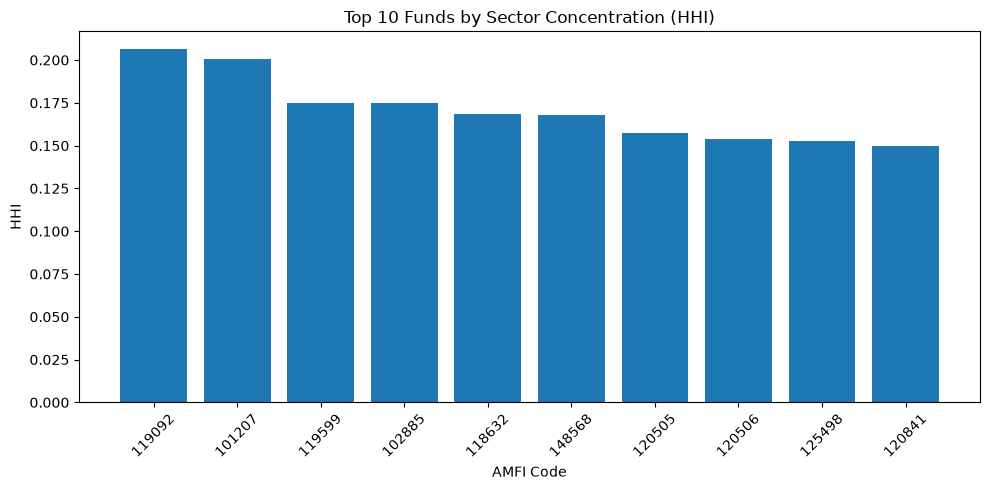

In [48]:
import matplotlib.pyplot as plt

top10 = sector_hhi.sort_values("HHI", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["amfi_code"].astype(str), top10["HHI"])
plt.title("Top 10 Funds by Sector Concentration (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/sector_hhi_chart.png")
plt.show()

In [49]:
sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("Sector HHI Report saved successfully!")


Sector HHI Report saved successfully!


# Advanced Analytics Summary

## Historical VaR & CVaR
- Calculated 95% Historical VaR and CVaR for all mutual funds.
- Identified downside risk using daily return distributions.

## Rolling Sharpe Ratio
- Computed 90-day rolling Sharpe Ratio.
- Evaluated changes in risk-adjusted performance over time.

## Investor Cohort Analysis
- Grouped investors based on their first investment month.
- Measured investor retention across cohorts.

## SIP Continuation Analysis
- Identified consistent and dropped SIP investors.
- Analysed investment continuity.

## Fund Recommendation System
- Ranked funds using Final Score.
- Recommended top-performing funds.

## Sector Concentration (HHI)
- Calculated HHI using portfolio holdings.
- Classified funds into Low, Moderate and High concentration risk.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np